# 분류 모델링 실습

## 위스콘신 유방암 데이터 예측
### 종양의 크기, 모양 등 다양한 속성값을 기반으로 유방암 양성인지 음성인지를 분류함



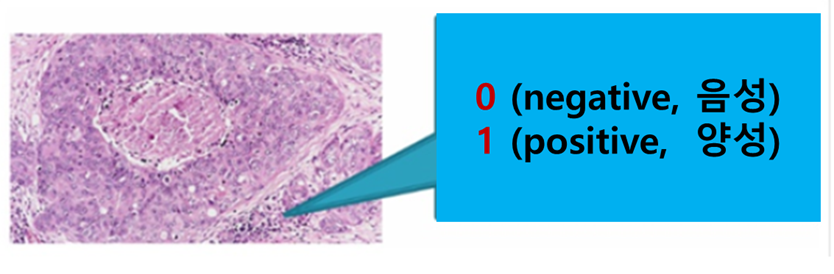
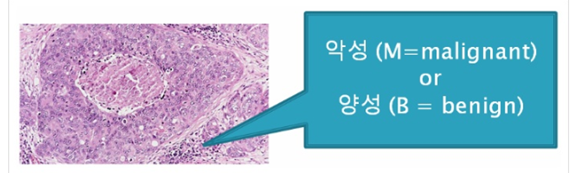

## 실습 순서 이해 
다음 순서로 실습을 해 본다.
- (1) 라이브러리/모듈 import
- (2) 위스콘신 유방암 데이터 세트 호출 (load_breast_cancer())
- (3) 데이터를 학습데이터와 테스트 데이터로 분리
- (4) 분석 모델 적용
    - 로지스틱 회귀, K-nn, Decision Tree
    - RandomForest, Extratree, XGB, LBGM 등 분류모델 사용 

### 1) 라이브러리/모듈 import

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

### 2) 데이터 로드 & Dataframe으로 변환

In [98]:
df = pd.read_csv('cancer.csv')
df  

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


### feature 30개열 + target 1개열

In [99]:
#X와 y를 분리해 봅니다.

X= df.drop('target', axis=1)
y= df['target']

### X->2d (dataframe) 
### y->1d (series)

In [100]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [101]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

### 3) 학습과 검증 데이터 셋 분리
- train_test_split을 이용한다.
- 단, X_train, X_val, y_train, y_val으로 설정 
- test_size=0.2 

In [102]:
#train_test_split을 이용하여 훈련용과 검증용을 나눕니다. 
#(test_size =0.2, random_sate = 156)

X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2 , random_state= 156)

### 4) 개별모델로 학습/예측/성능평가
#### 1) LogisticRegression
- 로지스틱회귀분석 실시한다. 

In [103]:
#로지스틱 회귀 class import
from sklearn.linear_model import LogisticRegression

In [104]:
# 객체생성
lr_clf = LogisticRegression()   

# 학습 
lr_clf.fit(X_train , y_train)

# 예측 
pred_lr = lr_clf.predict(X_val)

# 성능평가 - accuracy  
accuracy_score(y_val , pred_lr)

0.9385964912280702

#### 2) KNN

In [105]:
#K-nn class import

from sklearn.neighbors import KNeighborsClassifier

In [106]:
# 객체생성
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 학습 
knn_clf.fit(X_train, y_train)

# 예측 
pred_knn = knn_clf.predict(X_val)

# 성능평가
accuracy_score(y_val , pred_knn)

0.9385964912280702

In [107]:
for i in range(1,11):
    knn_clf = KNeighborsClassifier(n_neighbors=i)
    knn_clf.fit(X_train, y_train)
    pred_knn=knn_clf.predict(X_val)
    accuracy_knn = accuracy_score(y_val , pred_knn)
    print('k= {:d} 일 때 KNN 정확도: {:.4f}'.format(i, accuracy_knn))

k= 1 일 때 KNN 정확도: 0.9211
k= 2 일 때 KNN 정확도: 0.8947
k= 3 일 때 KNN 정확도: 0.9035
k= 4 일 때 KNN 정확도: 0.9211
k= 5 일 때 KNN 정확도: 0.9035
k= 6 일 때 KNN 정확도: 0.9211
k= 7 일 때 KNN 정확도: 0.9474
k= 8 일 때 KNN 정확도: 0.9386
k= 9 일 때 KNN 정확도: 0.9649
k= 10 일 때 KNN 정확도: 0.9474


#### 3) DecisionTree 

In [108]:
#Decision Tree class import
from sklearn.tree import DecisionTreeClassifier

- "blank"에 알맞은 메소드 넣기

In [109]:
# 객체생성
dt_clf = DecisionTreeClassifier()

# 학습
dt_clf.fit(X_train , y_train)

# 예측
pred = dt_clf.predict(X_val)

# 평가
accuracy_score(y_val , pred)

0.9473684210526315

#### 4) 랜덤 포레스트의 학습/ 예측 / 평가

In [110]:
#Random Forest class import
from sklearn.ensemble import RandomForestClassifier

In [111]:
# 객체생성
rf_clf = RandomForestClassifier()

# 학습
rf_clf.fit(X_train , y_train)

# 예측 
pred = rf_clf.predict(X_val)

# 평가
accuracy = accuracy_score(y_val, pred)

#### 5) ExtraTreesClassifier 

In [112]:
#ExtraTrees class import
from sklearn.ensemble import ExtraTreesClassifier

In [113]:
#직접 해 보세요!
# 객체생성
ex_clf = ExtraTreesClassifier(random_state=0)

# 학습   
ex_clf.fit(X_train, y_train)

# 예측 
pred = ex_clf.predict(X_val)   

# 평가
accuracy_score(y_val, pred)

0.9473684210526315

#### 6) XGB

In [114]:
#XGB class import
from xgboost import XGBClassifier

In [115]:
# 객체생성
xgb_clf = XGBClassifier()

# 학습
xgb_clf.fit(X_train , y_train)

# 예측
pred = xgb_clf.predict(X_val)

# 평가
accuracy_score(y_val, pred)


0.9649122807017544

#### 7) LGBM

In [116]:
#LGBM class import
from lightgbm import LGBMClassifier

In [117]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
172,15.460,11.89,102.50,736.9,0.12570,0.15550,0.203200,0.10970,0.1966,0.07069,...,18.79,17.04,125.00,1102.0,0.1531,0.3583,0.58300,0.18270,0.3216,0.10100
160,11.750,20.18,76.10,419.8,0.10890,0.11410,0.068430,0.03738,0.1993,0.06453,...,13.32,26.21,88.91,543.9,0.1358,0.1892,0.19560,0.07909,0.3168,0.07987
173,11.080,14.71,70.21,372.7,0.10060,0.05743,0.023630,0.02583,0.1566,0.06669,...,11.35,16.82,72.01,396.5,0.1216,0.0824,0.03938,0.04306,0.1902,0.07313
504,9.268,12.87,61.49,248.7,0.16340,0.22390,0.097300,0.05252,0.2378,0.09502,...,10.28,16.38,69.05,300.2,0.1902,0.3441,0.20990,0.10250,0.3038,0.12520
476,14.200,20.53,92.41,618.4,0.08931,0.11080,0.050630,0.03058,0.1506,0.06009,...,16.45,27.26,112.10,828.5,0.1153,0.3429,0.25120,0.13390,0.2534,0.07858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,11.520,18.75,73.34,409.0,0.09524,0.05473,0.030360,0.02278,0.1920,0.05907,...,12.84,22.47,81.81,506.2,0.1249,0.0872,0.09076,0.06316,0.3306,0.07036
10,16.020,23.24,102.70,797.8,0.08206,0.06669,0.032990,0.03323,0.1528,0.05697,...,19.19,33.88,123.80,1150.0,0.1181,0.1551,0.14590,0.09975,0.2948,0.08452
485,12.450,16.41,82.85,476.7,0.09514,0.15110,0.154400,0.04846,0.2082,0.07325,...,13.78,21.03,97.82,580.6,0.1175,0.4061,0.48960,0.13420,0.3231,0.10340
418,12.700,12.17,80.88,495.0,0.08785,0.05794,0.023600,0.02402,0.1583,0.06275,...,13.65,16.92,88.12,566.9,0.1314,0.1607,0.09385,0.08224,0.2775,0.09464


In [118]:
# estimator생성
lgb_clf = LGBMClassifier(verbose=-1)

# 학습
lgb_clf.fit(X_train , y_train)

# 예측 
pred = lgb_clf.predict(X_val)

#평가
accuracy_score(y_val, pred)

0.956140350877193

## 분류모델의 평가지표 - accuracy, precision, recall, f1
### confusion matrix

In [119]:
#confusion matrix 
from sklearn.metrics import confusion_matrix 

confusion_matrix(y_val, pred)   #실제값, 예측값

array([[33,  4],
       [ 1, 76]], dtype=int64)

### accuracy_score, precision_score, recall_score, f1_score

In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [121]:
#accuracy
accuracy_score(y_val,pred)

0.956140350877193

In [122]:
#precision
precision_score(y_val,pred)

0.95

In [123]:
#recall
recall_score(y_val, pred)

0.987012987012987

In [124]:
#f1
f1_score(y_val, pred)

0.9681528662420381